In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
from remotezip import RemoteZip
from pathlib import PurePosixPath, Path
from rasterio.io import MemoryFile
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import transform

In [2]:
folder_path = Path("all_fires/")
parquet_files=[]
for file_path in folder_path.iterdir():
  if file_path.is_file():
      if file_path.name.startswith("."):
          continue
      else:
        parquet_files.append(file_path.name)

In [ ]:
URL = "https://zenodo.org/records/8006177/files/WildfireSpreadTS.zip?download=1"
OUT = Path("all_fires")
OUT.mkdir(exist_ok=True)

YEARS = {"2018", "2019", "2020", "2021"}

FEATURES = [
    "viirs_m11",
    "viirs_i2",
    "viirs_i1",
    "ndvi",
    "evi2",
    "total_precipitation",
    "wind_speed",
    "wind_direction",
    "minimum_temperature",
    "maximum_temperature",
    "energy_release_component",
    "specific_humidity",
    "slope",
    "aspect",
    "elevation",
    "pdsi",
    "landcover_class",
    "forecast_total_precipitation",
    "forecast_wind_speed",
    "forecast_wind_direction",
    "forecast_temperature",
    "forecast_specific_humidity",
    "active_fire",
]
with RemoteZip(URL) as z:
    tif_files = [n for n in z.namelist() if n.lower().endswith(".tif")]
    fire_to_files = {}

    for name in tif_files:
        parts = PurePosixPath(name).parts

        for i, part in enumerate(parts):
            if part in YEARS and i + 1 < len(parts):
                fire = (part, parts[i + 1])
                fire_to_files.setdefault(fire, []).append(name)
                break
    original=[(year, fire_name)for year, fire_name in fire_to_files]
    selected = [
        (year, fire_name)
        for year, fire_name in fire_to_files
        if f"{year}_{fire_name}.parquet" not in parquet_files
    ]
    print("\nSelected fires:")
    index = next(i for i, x in enumerate(original) if x[1] == "fire_21889798")
    print(index)
    new_selected=original[index:]

    for i, (year, fire_name) in enumerate(new_selected, 1):
        print(f"Processed {index+i}/{len(original)}")
        files = sorted(fire_to_files[(year, fire_name)])
        burning_dates = []

        for tif_name in files:
            with z.open(tif_name) as f:
                tif_bytes = f.read()
        
            with MemoryFile(tif_bytes) as mem:
                with mem.open() as src:
                    active_fire = src.read(FEATURES.index("active_fire") + 1)
        
                    # This date actually contains active fire
                    if not np.isnan(active_fire).all():
                        filename = PurePosixPath(tif_name).stem
                        match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
        
                        if match:
                            burning_dates.append(pd.Timestamp(match.group(0)))
        
        burning_dates = sorted(set(burning_dates))
        
        has_5_consecutive = any(
            all(
                burning_dates[i + j] - burning_dates[i + j - 1]
                == pd.Timedelta(days=1)
                for j in range(1, 5)
            )
            for i in range(len(burning_dates) - 4)
        )
        
        if not has_5_consecutive:
            continue
 
        output = OUT / f"{year}_{fire_name}.parquet"
        print(f"Output: {output}")

        writer = None

        for n, tif_name in enumerate(files, 1):
            with z.open(tif_name) as f:
                tif_bytes = f.read()

            with MemoryFile(tif_bytes) as mem:
                with mem.open() as src:
                    arr = src.read()      # (bands, height, width)
                    bands, height, width = arr.shape
                    active_fire = arr[FEATURES.index("active_fire")]
                    
                    if np.isnan(active_fire).all():
                        continue
                    rows, cols = np.indices((height, width))

                    # Geographic x/y coordinates
                    xs, ys = src.xy(rows.ravel(), cols.ravel())
                    lons, lats = transform(src.crs, "EPSG:4326", xs, ys)

                    filename = PurePosixPath(tif_name).stem

                    # Extract YYYY-MM-DD from filename
                    match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
                    date = match.group(0) if match else filename

                    data = {
                        "fire": np.repeat(fire_name, height * width),
                        "year": np.repeat(int(year), height * width),
                        "date": np.repeat(date, height * width),
                        "row": rows.ravel(),
                        "col": cols.ravel(),
                        "x": np.asarray(xs),
                        "y": np.asarray(ys),
                        "longitude": np.asarray(lons),
                        "latitude": np.asarray(lats),
                    }
                        

                    
                    assert bands == len(FEATURES), f"Expected 23 bands, got {bands}"
                    
                    for b, feature in enumerate(FEATURES):
                        data[feature] = arr[b].ravel()
    

                    table = pa.Table.from_pydict(data)

                    if writer is None:
                        writer = pq.ParquetWriter(
                            output,
                            table.schema,
                            compression="zstd",
                            compression_level=9
                        )

                    writer.write_table(table)

        if writer is not None:
            writer.close()

        print(f"Saved {output}")




Selected fires:
122
Processed 123/607
Output: all_fires/2018_fire_21889798.parquet


In [ ]:
print("hi")

In [22]:
collections, fire_masks = [], []

features = [
    'total_precipitation', 'wind_speed', 'wind_direction',
    'energy_release_component', 'specific_humidity',
    'pdsi', 'landcover_class'
]
fire_id="2018_fire_21889779"
for f in parquet_files:
    if fire_id in f:
        df = pd.read_parquet(f"six_fires_parquet/{f}")
    
        dates = sorted(df["date"].unique())
        df = df[df["date"].isin(dates)].copy()
    
        df["burning"] = df["active_fire"].notna().astype(float)
        df = df.sort_values(["x", "y", "date"])
    
        env = df.groupby(["x", "y"])[features].apply(lambda g: g.to_numpy())
        fire = df.groupby(["x", "y"])[["burning"]].apply(lambda g: g.to_numpy())

#     collections.append(torch.tensor(np.stack(env.values), dtype=torch.float32))
#     fire_masks.append(torch.tensor(np.stack(fire.values), dtype=torch.float32))

# print(collections[0].shape)
# print(fire_masks[0].shape)

In [8]:
df

,fire,year,date,row,col,x,y,viirs_m11,viirs_i2,viirs_i1,ndvi,evi2,total_precipitation,wind_speed,wind_direction,minimum_temperature,maximum_temperature,energy_release_component,specific_humidity,slope,aspect,elevation,pdsi,landcover_class,forecast_total_precipitation,forecast_wind_speed,forecast_wind_direction,forecast_temperature,forecast_specific_humidity,active_fire,burning
90072,fire_21748798,2018,2018-05-06,324,0,1425562.5,3827437.5,3255.0,3849.0,3231.0,1948.0,1344.0,0.0,4.3,122.0,291.299988,309.000000,102.0,0.00228,1.134709,215.187012,917.0,-3.85,7.0,0.0000,1.990038,-88.057976,26.043880,0.003239,NaN,0.0
180422,fire_21748798,2018,2018-05-07,324,0,1425562.5,3827437.5,4003.0,3333.0,2273.0,1948.0,1344.0,0.0,3.9,153.0,290.899994,307.399994,102.0,0.00252,1.134709,215.187012,917.0,-3.85,7.0,0.0000,1.964425,67.398315,25.330065,0.003074,NaN,0.0
270772,fire_21748798,2018,2018-05-08,324,0,1425562.5,3827437.5,3926.0,3165.0,2163.0,1948.0,1344.0,0.0,2.6,166.0,291.700012,308.899994,105.0,0.00215,1.134709,215.187012,917.0,-3.85,7.0,0.0000,3.630821,84.555168,24.125200,0.003679,NaN,0.0
361122,fire_21748798,2018,2018-05-09,324,0,1425562.5,3827437.5,3326.0,3114.0,2117.0,1948.0,1344.0,0.0,3.0,264.0,292.799988,308.799988,106.0,0.00211,1.134709,215.187012,917.0,-3.85,7.0,0.0000,4.028547,-84.013504,23.853359,0.003797,NaN,0.0
451472,fire_21748798,2018,2018-05-10,324,0,1425562.5,3827437.5,3203.0,2763.0,1851.0,1948.0,1344.0,0.0,5.6,200.0,291.600006,308.100006,106.0,0.00281,1.134709,215.187012,917.0,-3.85,7.0,0.0000,4.078687,-83.139816,22.393154,0.004028,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632727,fire_21748798,2018,2018-05-13,0,277,1529437.5,3948937.5,1895.0,2457.0,1004.0,4198.0,2443.0,0.0,5.5,216.0,270.200012,290.600006,70.0,0.00343,2.291260,19.262272,2189.0,-3.49,10.0,0.0000,3.442691,49.478657,12.147231,0.002978,NaN,0.0
723077,fire_21748798,2018,2018-05-14,0,277,1529437.5,3948937.5,1676.0,2006.0,881.0,4198.0,2443.0,0.0,4.7,207.0,270.200012,292.000000,70.0,0.00316,2.291260,19.262272,2189.0,-3.49,10.0,1.3125,3.485990,43.507168,12.902255,0.002925,NaN,0.0
813427,fire_21748798,2018,2018-05-15,0,277,1529437.5,3948937.5,1013.0,1659.0,673.0,4198.0,2443.0,0.0,5.0,225.0,271.299988,294.600006,71.0,0.00304,2.291260,19.262272,2189.0,-3.49,10.0,0.9375,3.340631,46.164928,12.425177,0.003046,NaN,0.0
903777,fire_21748798,2018,2018-05-16,0,277,1529437.5,3948937.5,1070.0,1602.0,583.0,4198.0,2443.0,0.0,4.4,226.0,272.399994,296.299988,75.0,0.00252,2.291260,19.262272,2189.0,-3.52,10.0,0.0000,3.333693,46.852001,13.162833,0.002894,NaN,0.0


In [12]:
df['burning'].value_counts()

burning
0.0    1084036
1.0        164
Name: count, dtype: int64

In [18]:
def plot_fire(df):
    fire_df = df.copy()
    xmin, xmax = fire_df["x"].min(), fire_df["x"].max()
    ymin, ymax = fire_df["y"].min(), fire_df["y"].max()
    
    ncols = 4
    nrows = int(np.ceil(len(dates) / ncols))
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4*ncols, 4*nrows),
        sharex=True,
        sharey=True,
        squeeze=False
    )
    
    for ax, date in zip(axes.flat, dates):
    
        day = fire_df[fire_df["date"] == date]
    
        ax.scatter(
            day["x"],
            day["y"],
            c=day["active_fire"],
            cmap="bwr",
            vmin=0,
            vmax=1,
            marker="s",
            s=10
        )
    
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
    
        ax.set_title(str(date))
    
    for ax in axes.flat[len(dates):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

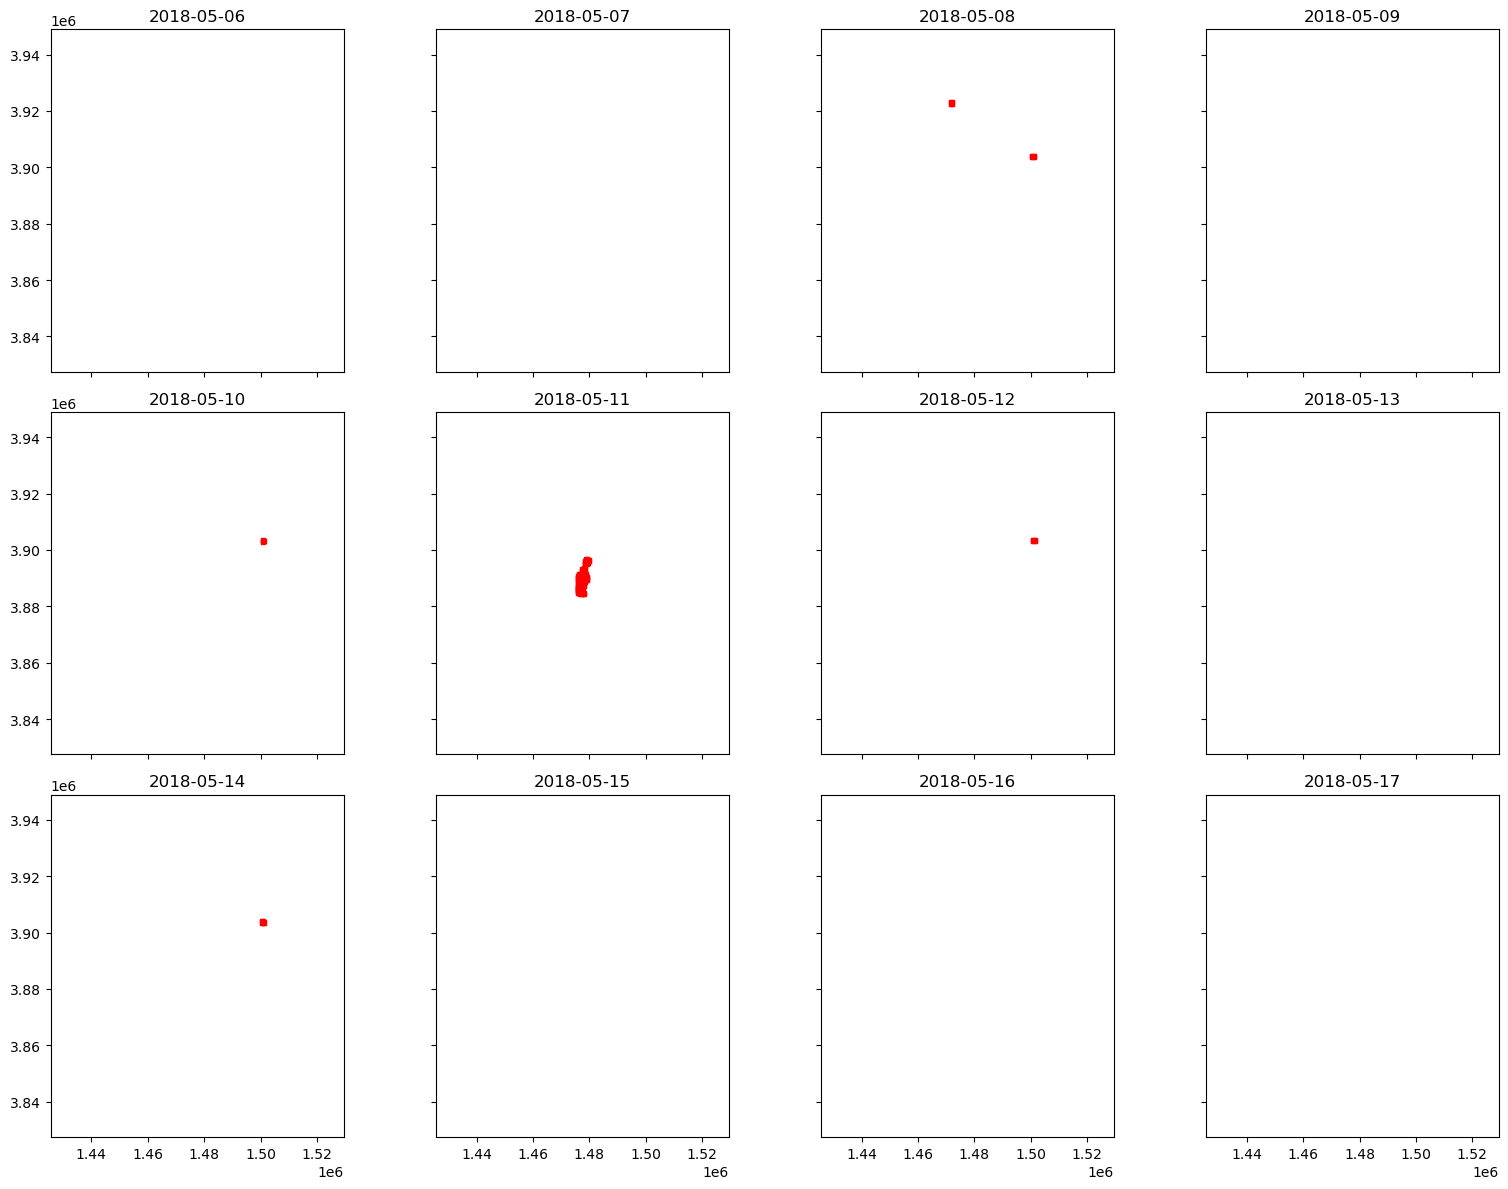

In [19]:
#fire_21748798
plot_fire(df)

2018_fire_21615469


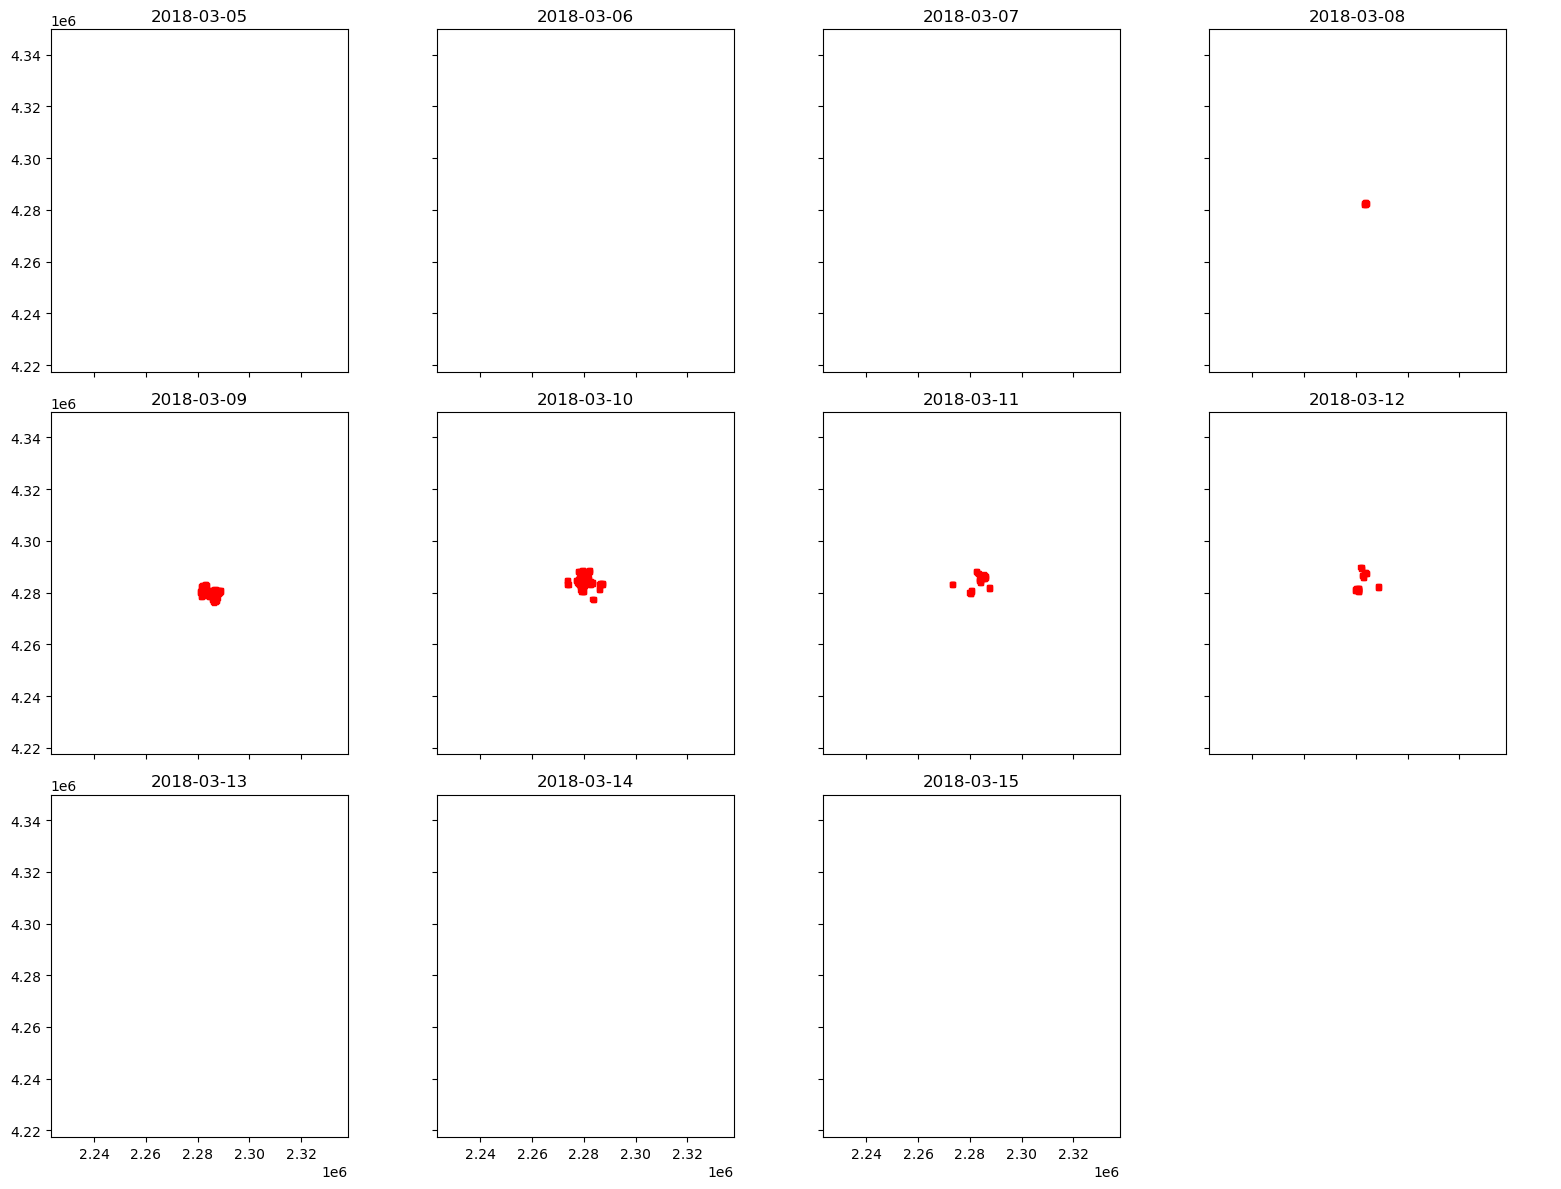

In [21]:
print(fire_id)
plot_fire(df)

2018_fire_21889779


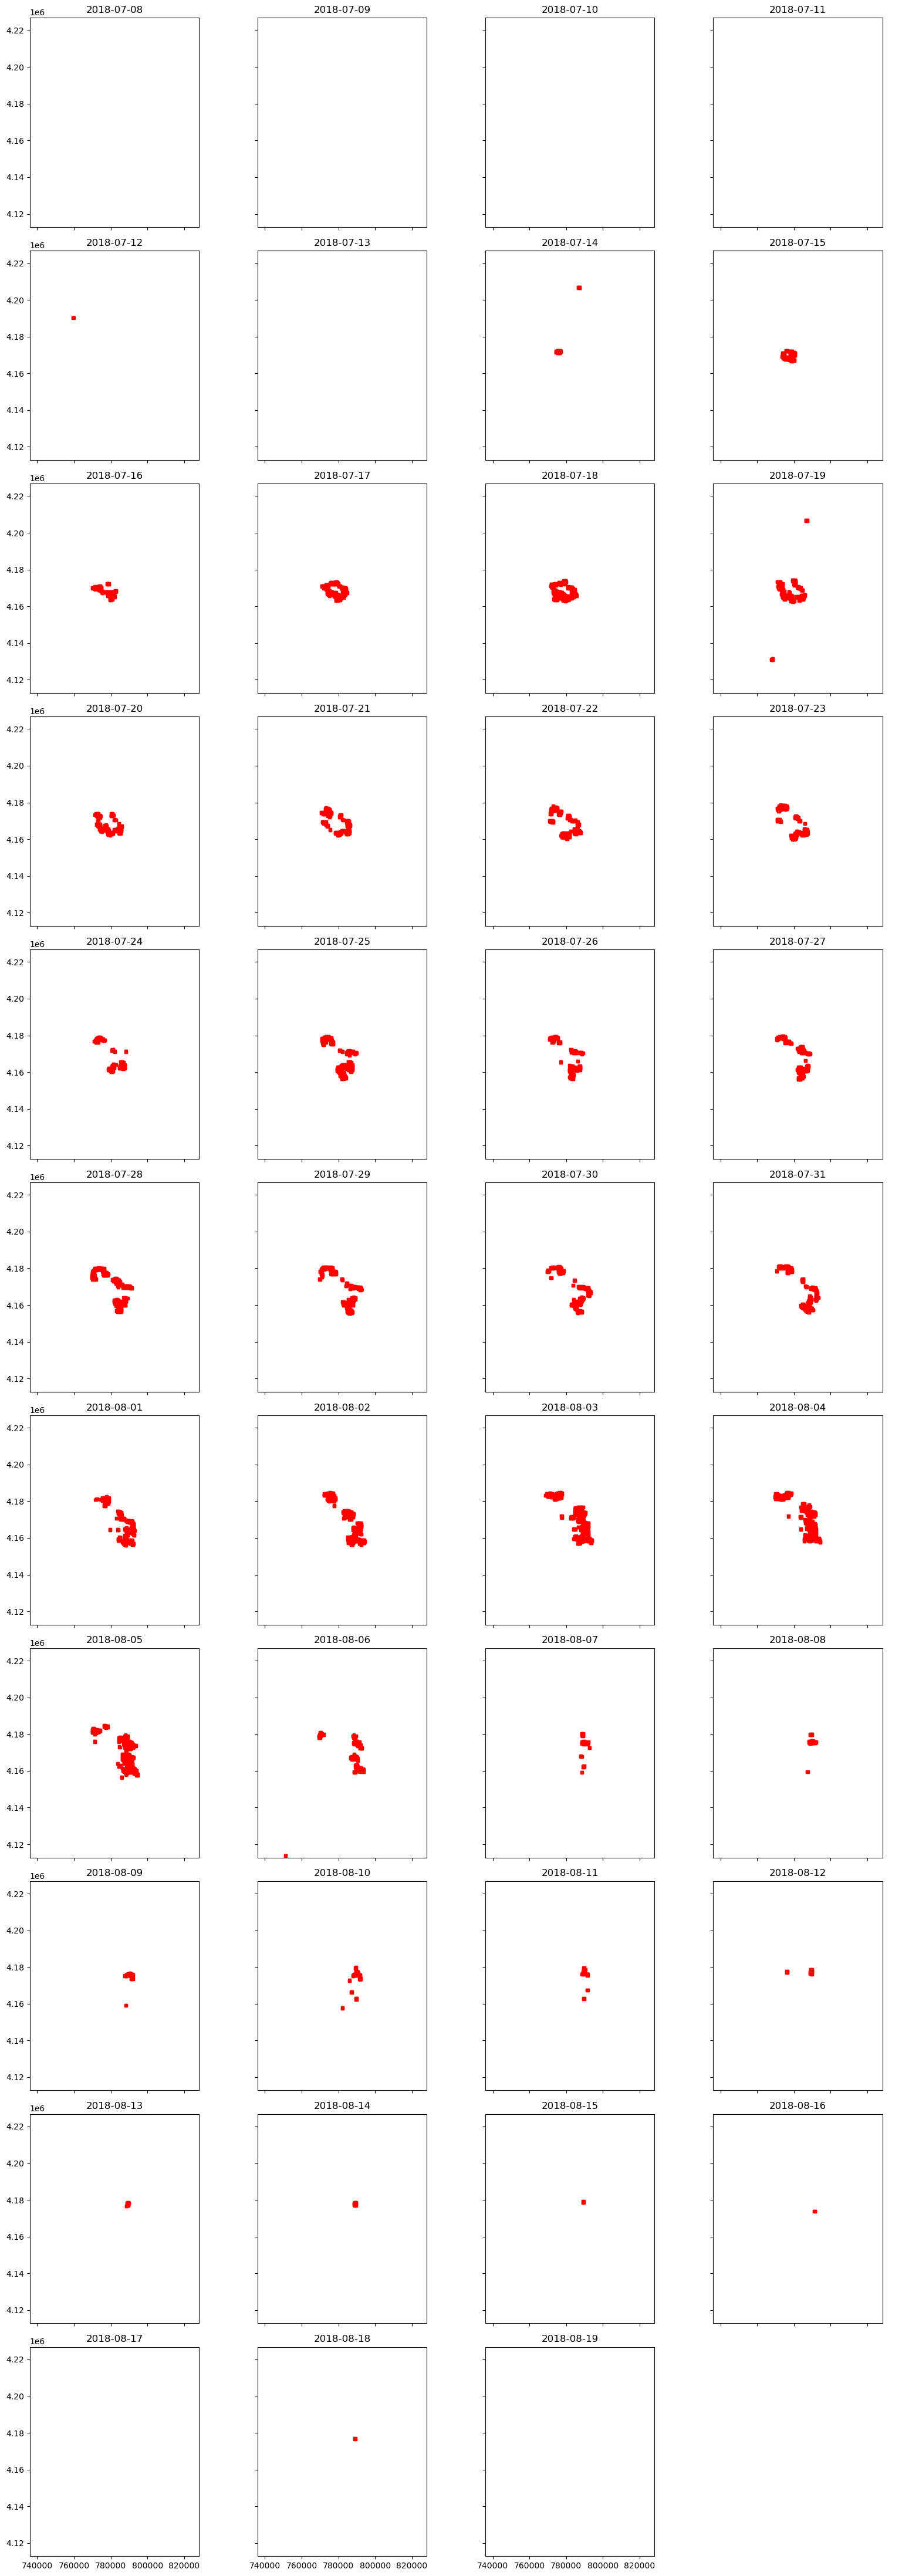

In [23]:
print(fire_id)
plot_fire(df)